# Outlier Detection and Influence Diagnostics in Panel Data

**Series:** panelbox Validation Tutorials  
**Notebook:** 03 — Outliers and Influence Analysis  
**Level:** Intermediate  
**Estimated duration:** 90–120 minutes

---

## Motivation

OLS minimises the sum of **squared** residuals, which makes it exquisitely sensitive to
extreme observations. A single badly-recorded data point can shift an entire regression
line. Before trusting your estimates, you need to know whether any observation is
pulling the results disproportionately.

## Three Distinct Concepts

| Concept | What it means | Primary measure |
|---------|--------------|----------------|
| **Outlier** | Observation with an unusually **large residual** | Studentised residual |
| **High-leverage point** | Observation with an extreme **X value** | Hat value hᵢᵢ |
| **Influential observation** | Removal **changes β̂** substantially | Cook's Distance |

These categories overlap but are **not identical**:

```
                 High leverage?
                 No               Yes
Large     |  Outlier only      |  Outlier + leverage        |
residual? |  (inflates SE,     |  (potentially very         |
          |   little effect    |   influential — beware!)   |
          |   on β̂)            |                            |
----------|--------------------|----------------------------|
Small     |  Unremarkable      |  High-leverage,            |
residual? |                    |  low influence             |
```

## Decision Workflow

1. **Identify** — run all diagnostics  
2. **Investigate** — is the observation a data-entry error or a legitimate extreme value?  
3. **Decide** — remove / use robust estimator / keep and report sensitivity  

Never silently drop observations. Always report the sensitivity analysis.

## Learning Objectives

By the end of this notebook you will be able to:

1. Distinguish outliers, high-leverage points, and influential observations  
2. Detect outliers using standardised and studentised residuals  
3. Compute leverage (hat values) and identify high-leverage observations  
4. Calculate Cook's Distance, DFFITS, and DFBETAS  
5. Apply leave-one-out sensitivity analysis at entity and period level  
6. Make transparent, defensible decisions about influential observations

In [1]:
# Cell 1 — Setup
import warnings
warnings.filterwarnings("ignore")

import sys
import pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from utils import load_dataset
from utils.plot_helpers import plot_influence_index, plot_forest_plot

from panelbox.models.static import FixedEffects
from panelbox.validation.robustness import (
    OutlierDetector,
    InfluenceDiagnostics,
    SensitivityAnalysis,
)

# Output directory
OUTPUT_DIR = pathlib.Path("..") / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete")

Setup complete


---
## Section 1 — Key Definitions and Thresholds

Before computing any diagnostics, let's fix the terminology and the standard thresholds
used throughout this notebook.

### Standard Thresholds

| Concept | Measure | Threshold |
|---------|---------|----------|
| Outlier | Studentised residual tᵢ | \|tᵢ\| > 3 |
| Leverage | Hat value hᵢᵢ | hᵢᵢ > 2k/n |
| Influence | Cook's D | Dᵢ > 4/n |
| Influence | DFFITS | \|DFFITSᵢ\| > 2√(k/n) |
| Influence | DFBETAS | \|DFBETASᵢⱼ\| > 2/√n |

where *k* = number of parameters and *n* = number of observations.

### Why Panel Data Complicates Things

In standard OLS the hat matrix **H = X(X'X)⁻¹X'** is easy to compute.
In a Fixed Effects model the "effective" design matrix is the **within-demeaned** X,
which absorbs entity fixed effects. This means:

- Leverage reflects extremity within entity, not in the raw data  
- An observation that looks unremarkable unconditionally may be extreme
  after demeaning  
- All diagnostics in this notebook are based on **within-transformed** residuals

In [2]:
# Cell 1.2 — Load and Inspect Datasets
df_outliers = load_dataset("panel_with_outliers")
print("panel_with_outliers shape:", df_outliers.shape)
print("\nOutlier flags distribution:")
print(df_outliers["outlier_flag"].value_counts())
print("  (0 = normal, 1 = injected outlier, 2 = natural extreme)")

df_firms = load_dataset("real_firms")
print("\nreal_firms shape:", df_firms.shape)
df_firms.head()

panel_with_outliers shape: (640, 6)

Outlier flags distribution:
outlier_flag
0    606
1     32
2      2
Name: count, dtype: int64
  (0 = normal, 1 = injected outlier, 2 = natural extreme)

real_firms shape: (600, 6)


,firm,year,roe,leverage,firm_age,industry
0,1,2018,-0.0529,0.5879,26,Technology
1,1,2019,-0.0363,0.5469,27,Technology
2,1,2020,-0.0019,0.5052,28,Technology
3,1,2021,-0.0234,0.5415,29,Technology
4,1,2022,-0.0199,0.5891,30,Technology


---
## Section 2 — Univariate Outlier Detection

### Methods

| Method | Formula | When to use |
|--------|---------|-------------|
| **IQR rule** | Outlier if \|x − median\| > 1.5 × IQR | Raw variable cleaning; robust to distribution shape |
| **Z-score** | Outlier if \|z\| > 3 | Approximately normal variables |
| **Standardised residuals** | rᵢ = εᵢ / σ̂ | After model fitting; fast |
| **Studentised residuals** | tᵢ = εᵢ / (σ̂₍₋ᵢ₎ √(1 − hᵢᵢ)) | After model fitting; most precise |

The residual-based methods are preferred because they account for the model structure.
The IQR and Z-score methods are useful for **data cleaning before estimation**.

In [3]:
# Cell 2.2 — Fit Fixed Effects Model on Outlier Dataset
fe_outliers = FixedEffects(
    formula="profit ~ revenue + costs",
    data=df_outliers,
    entity_col="firm",
    time_col="year",
).fit()

print(fe_outliers.summary())

                       Fixed Effects Estimation Results                       
Formula: profit ~ revenue + costs
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:                 640
No. Entities:                      80
No. Time Periods:                   8
Degrees of Freedom:               558
R-squared:                     0.1760
Adj. R-squared:                0.0564
R-squared (within):            0.1760
R-squared (between):           1.0000
R-squared (overall):           0.7397
Standard Errors:            nonrobust
F-statistic (FE vs OLS):       1.2026
F-test p-value:                0.1247
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
revenue              1.1032      0.1011  10.915  0.0000    0.9047    1.3017 ***
costs               -1.0619      0.1271  -8.353  0.0000   -1.3116   -0.8122 ***
Signif. 

In [4]:
# Cell 2.3 — Detect Outliers: Standardised Residuals
detector = OutlierDetector(fe_outliers)
result_std = detector.detect_outliers_residuals(method="standardized", threshold=3.0)

# Isolate the flagged rows
outlier_table_std = result_std.outliers[result_std.outliers["is_outlier"]].copy()

print(f"Outliers detected (standardised, threshold=3): {result_std.n_outliers}")
print(outlier_table_std.head(10))

Detected 20 outliers using standardized residuals
Outliers detected (standardised, threshold=3): 20
     entity  time    residual  standardized_residual  is_outlier  distance
52        7  2019   95.071188               3.214473        True  3.214473
58        8  2017 -166.577347              -5.632183        True  5.632183
115      15  2018 -160.773519              -5.435949        True  5.435949
124      16  2019  124.663259               4.215017        True  4.215017
145      19  2016 -109.650601              -3.707421        True  3.707421
233      30  2016  125.097162               4.229688        True  4.229688
255      32  2022 -104.600935              -3.536685        True  3.536685
282      36  2017  122.737502               4.149905        True  4.149905
287      36  2022 -164.984151              -5.578315        True  5.578315
325      41  2020 -157.381113              -5.321247        True  5.321247


In [5]:
# Cell 2.4 — Detect Outliers: Studentised Residuals
result_stud = detector.detect_outliers_residuals(method="studentized", threshold=3.0)

outlier_table_stud = result_stud.outliers[result_stud.outliers["is_outlier"]].copy()

print(f"Outliers detected (studentised, threshold=3): {result_stud.n_outliers}")
print(outlier_table_stud.head(10))

Detected 20 outliers using studentized residuals
Outliers detected (studentised, threshold=3): 20
     entity  time    residual  studentized_residual  is_outlier  distance
52        7  2019   95.071188              3.219507        True  3.219507
58        8  2017 -166.577347             -5.641004        True  5.641004
115      15  2018 -160.773519             -5.444462        True  5.444462
124      16  2019  124.663259              4.221618        True  4.221618
145      19  2016 -109.650601             -3.713227        True  3.713227
233      30  2016  125.097162              4.236312        True  4.236312
255      32  2022 -104.600935             -3.542224        True  3.542224
282      36  2017  122.737502              4.156404        True  4.156404
287      36  2022 -164.984151             -5.587052        True  5.587052
325      41  2020 -157.381113             -5.329581        True  5.329581


In [6]:
# Cell 2.5 — Validate Against Known Outlier Flags
# The dataset has an 'outlier_flag' column:
#   1 = artificially injected outlier (known true positives)
# We compare the detector's output against these ground-truth flags.

# Detected outlier row positions (integer index)
detected_positions = set(outlier_table_stud.index.tolist())

# True outlier row positions (flag == 1 only; flag == 2 are natural extremes)
true_positions = set(df_outliers.index[df_outliers["outlier_flag"] == 1].tolist())

true_pos  = len(detected_positions & true_positions)
false_pos = len(detected_positions - true_positions)
false_neg = len(true_positions - detected_positions)

print("Confusion matrix (studentised residuals, threshold=3):")
print(f"  True positives  (correctly flagged injected outliers): {true_pos}")
print(f"  False positives (flagged but not injected)            : {false_pos}")
print(f"  False negatives (injected but not flagged)            : {false_neg}")
print(f"  Precision: {true_pos/(true_pos+false_pos):.2%}" if (true_pos+false_pos)>0 else "  No detections")
print(f"  Recall   : {true_pos/(true_pos+false_neg):.2%}" if (true_pos+false_neg)>0 else "  No true outliers")

Confusion matrix (studentised residuals, threshold=3):
  True positives  (correctly flagged injected outliers): 20
  False positives (flagged but not injected)            : 0
  False negatives (injected but not flagged)            : 12
  Precision: 100.00%
  Recall   : 62.50%


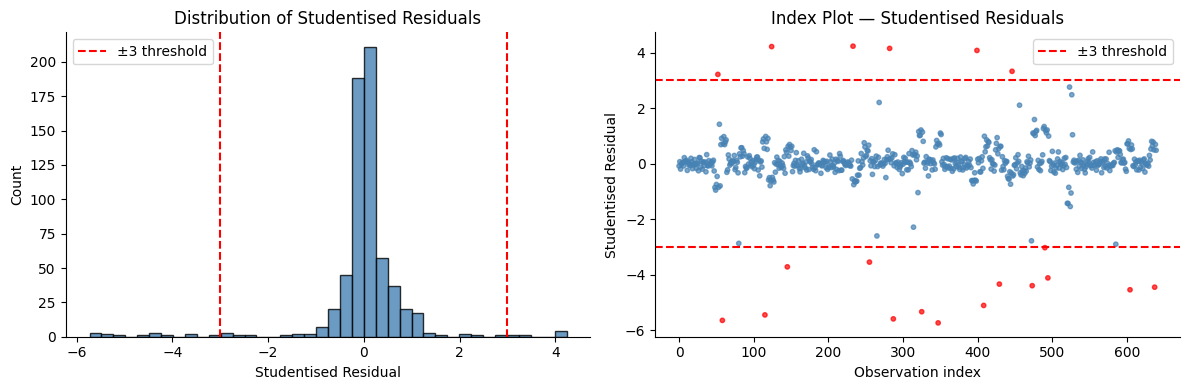

Saved: outputs/03_studentised_residuals.png


In [7]:
# Cell 2.6 — Visualize Residuals
# Extract the studentised residual column from the full OutlierResults DataFrame
stud_resid_series = result_stud.outliers["studentized_residual"].values
is_outlier_mask   = result_stud.outliers["is_outlier"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: Histogram of studentised residuals ---
axes[0].hist(stud_resid_series, bins=40, edgecolor="black",
             color="steelblue", alpha=0.8)
axes[0].axvline( 3, color="red", linestyle="--", label="±3 threshold")
axes[0].axvline(-3, color="red", linestyle="--")
axes[0].set_title("Distribution of Studentised Residuals")
axes[0].set_xlabel("Studentised Residual")
axes[0].set_ylabel("Count")
axes[0].legend()

# --- Right: Index plot coloured by outlier status ---
colors = ["red" if o else "steelblue" for o in is_outlier_mask]
axes[1].scatter(range(len(stud_resid_series)), stud_resid_series,
                c=colors, s=10, alpha=0.7)
axes[1].axhline( 3, color="red", linestyle="--", label="±3 threshold")
axes[1].axhline(-3, color="red", linestyle="--")
axes[1].set_title("Index Plot — Studentised Residuals")
axes[1].set_xlabel("Observation index")
axes[1].set_ylabel("Studentised Residual")
axes[1].legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_studentised_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_studentised_residuals.png")

---
## Section 3 — Leverage Diagnostics

### Hat Values

The **hat matrix** H = X(X'X)⁻¹X' projects the response vector **y** onto the
column space of **X**. The diagonal element hᵢᵢ measures how far observation i is
from the centroid of the regressors:

- hᵢᵢ ∈ [0, 1]
- Σhᵢᵢ = k (trace = number of parameters including intercept)
- Average leverage = k/n
- **Threshold:** hᵢᵢ > 2k/n → high leverage

**Important:** high leverage ≠ influential. An observation that is extreme in
X-space but sits close to the regression line (small residual) has high leverage
but may not change β̂ at all if removed.

The most dangerous configuration is **high leverage + large residual** — the
upper-right quadrant of the leverage-vs-residuals scatter plot.

In [8]:
# Cell 3.2 — Compute Leverage
influence = InfluenceDiagnostics(fe_outliers)
infl_results = influence.compute()

leverage  = infl_results.leverage
n_params  = fe_outliers.params.shape[0]
n_obs     = fe_outliers.nobs
threshold_leverage = 2 * n_params / n_obs

high_leverage = leverage[leverage > threshold_leverage]
print(f"Observations          : {n_obs}")
print(f"Parameters            : {n_params}")
print(f"Leverage threshold (2k/n): {threshold_leverage:.4f}")
print(f"High-leverage observations: {len(high_leverage)}")
print("\nTop 10 by leverage value:")
print(leverage.nlargest(10))

Computing influence diagnostics...
Influence diagnostics computed successfully
Observations          : 640
Parameters            : 2
Leverage threshold (2k/n): 0.0063
High-leverage observations: 142

Top 10 by leverage value:
247    0.018106
32     0.017605
635    0.017508
315    0.016008
65     0.015419
407    0.015156
356    0.014079
394    0.013962
135    0.013453
575    0.012776
dtype: float64


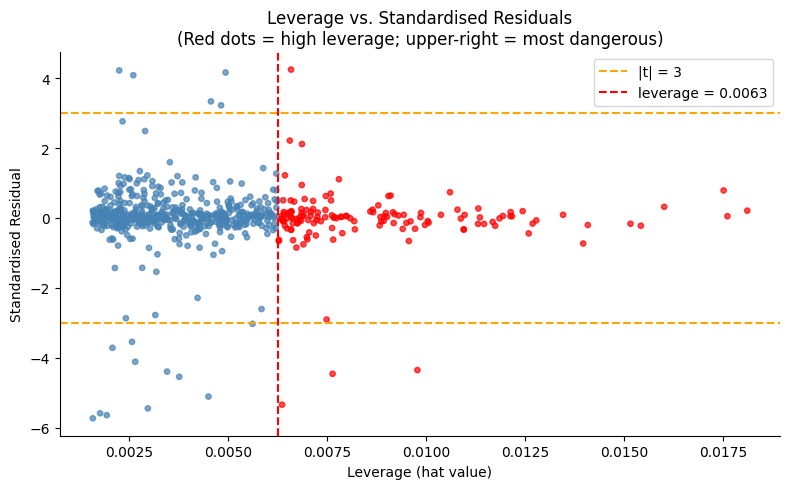

Saved: outputs/03_leverage_vs_residuals.png


In [9]:
# Cell 3.3 — Scatter Plot: Leverage vs. Studentised Residuals
stud_resid_vals = infl_results.standardized_residuals.values
leverage_vals   = leverage.values

colors = [
    "red" if (h > threshold_leverage) else "steelblue"
    for h in leverage_vals
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(leverage_vals, stud_resid_vals, c=colors, s=15, alpha=0.7)
ax.axhline( 3, color="orange", linestyle="--", label="|t| = 3")
ax.axhline(-3, color="orange", linestyle="--")
ax.axvline(threshold_leverage, color="red", linestyle="--",
           label=f"leverage = {threshold_leverage:.4f}")
ax.set_xlabel("Leverage (hat value)")
ax.set_ylabel("Standardised Residual")
ax.set_title("Leverage vs. Standardised Residuals\n"
             "(Red dots = high leverage; upper-right = most dangerous)")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_leverage_vs_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_leverage_vs_residuals.png")

---
## Section 4 — Cook's Distance

### Formula and Interpretation

**Cook's Distance** combines the residual magnitude and the leverage into a single
composite measure:

$$D_i = \frac{r_i^2}{k} \cdot \frac{h_{ii}}{(1 - h_{ii})^2}$$

where rᵢ is the standardised residual, k is the number of parameters, and hᵢᵢ is
the hat value.

**Thresholds:**
- Dᵢ > 4/n — moderately influential (flag for inspection)
- Dᵢ > 1 — highly influential (strong evidence of undue influence)

**Important nuance:** high Cook's D means **influential**, not necessarily **erroneous**.
Always investigate the observation before deciding to remove it.

In [10]:
# Cell 4.2 — Compute Cook's Distance
cooks_d = infl_results.cooks_d
threshold_cook = 4 / n_obs

influential = cooks_d[cooks_d > threshold_cook]
print(f"Cook's D threshold (4/n = 4/{n_obs}): {threshold_cook:.5f}")
print(f"Influential observations (Cook's D > threshold): {len(influential)}")
print("\nTop 10 by Cook's D:")
print(influential.sort_values(ascending=False).head(10))

Cook's D threshold (4/n = 4/640): 0.00625
Influential observations (Cook's D > threshold): 29

Top 10 by Cook's D:
429    0.093347
325    0.091136
637    0.076326
233    0.059665
408    0.058891
115    0.044073
282    0.042870
604    0.038877
473    0.033400
585    0.031794
dtype: float64


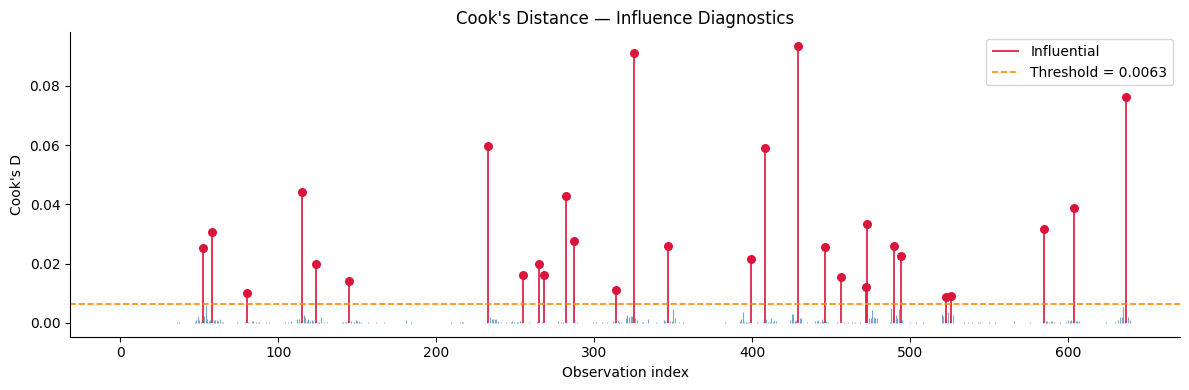

Saved: outputs/03_cooks_distance.png


In [11]:
# Cell 4.3 — Index Plot with Threshold
fig = plot_influence_index(
    cooks_d=cooks_d.values,
    threshold=threshold_cook,
    title="Cook's Distance — Influence Diagnostics",
)
fig.savefig(OUTPUT_DIR / "03_cooks_distance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_cooks_distance.png")

In [12]:
# Cell 4.4 — Investigate Top Influential Observations
top5_idx = cooks_d.nlargest(5).index.tolist()

print("Top 5 most influential observations:")
print(df_outliers.loc[top5_idx, ["firm", "year", "profit", "revenue",
                                  "costs", "outlier_flag"]])

print("\nCook's D values:")
print(cooks_d.loc[top5_idx].round(6))

Top 5 most influential observations:
     firm  year    profit   revenue     costs  outlier_flag
429    54  2020   35.2258  490.0211  308.6845             1
325    41  2020  -43.6622  391.2696  249.6357             1
637    80  2020   57.6939  506.6400  300.3402             1
233    30  2016  194.3187  108.0425   56.3750             1
408    52  2015  -86.6209  246.5233  160.4015             1

Cook's D values:
429    0.093347
325    0.091136
637    0.076326
233    0.059665
408    0.058891
dtype: float64


---
## Section 5 — DFFITS and DFBETAS

### DFFITS — Change in Fitted Value

DFFITS measures how much the **fitted value** for observation i changes when i is
removed from the dataset:

$$\text{DFFITS}_i = t_i \sqrt{\frac{h_{ii}}{1 - h_{ii}}}$$

**Threshold:** |DFFITSᵢ| > 2√(k/n)

### DFBETAS — Change in Each Coefficient

DFBETAS measures how much **coefficient j** changes when observation i is removed,
standardised by the standard error:

$$\text{DFBETAS}_{ij} = \frac{\hat{\beta}_j - \hat{\beta}_{j(-i)}}{\widehat{SE}(\hat{\beta}_{j(-i)})}$$

**Threshold:** |DFBETASᵢⱼ| > 2/√n

**Most informative aspect:** DFBETAS shows *which coefficient* is most affected
by each observation — much more specific than Cook's D.

In [13]:
# Cell 5.2 — DFFITS
dffits = infl_results.dffits
threshold_dffits = 2 * np.sqrt(n_params / n_obs)

high_dffits = dffits[abs(dffits) > threshold_dffits]
print(f"DFFITS threshold (2√(k/n)): {threshold_dffits:.4f}")
print(f"Observations with high |DFFITS|: {len(high_dffits)}")
print("\nTop 10 by |DFFITS|:")
print(dffits.abs().nlargest(10))

DFFITS threshold (2√(k/n)): 0.1118
Observations with high |DFFITS|: 29

Top 10 by |DFFITS|:
429    0.432082
325    0.426933
637    0.390707
233    0.345443
408    0.343193
115    0.296894
282    0.292814
604    0.278845
473    0.258456
585    0.252166
dtype: float64


In [14]:
# Cell 5.3 — DFBETAS
dfbetas = infl_results.dfbetas   # DataFrame: observations × parameters

threshold_dfbetas = 2 / np.sqrt(n_obs)
print(f"DFBETAS threshold (2/√n): {threshold_dfbetas:.4f}")
print(f"Parameters: {dfbetas.columns.tolist()}")

# Observations with high DFBETAS for ANY parameter
high_dfbetas_mask = (dfbetas.abs() > threshold_dfbetas).any(axis=1)
print(f"Observations with high DFBETAS (any param): {high_dfbetas_mask.sum()}")
print("\nSample (top 10 by max absolute DFBETAS):")
top_dfbetas = dfbetas[high_dfbetas_mask].copy()
top_dfbetas["max_abs"] = top_dfbetas.abs().max(axis=1)
print(top_dfbetas.nlargest(10, "max_abs").drop(columns="max_abs").round(4))

DFBETAS threshold (2/√n): 0.0791
Parameters: ['revenue', 'costs']
Observations with high DFBETAS (any param): 0

Sample (top 10 by max absolute DFBETAS):
Empty DataFrame
Columns: [revenue, costs]
Index: []


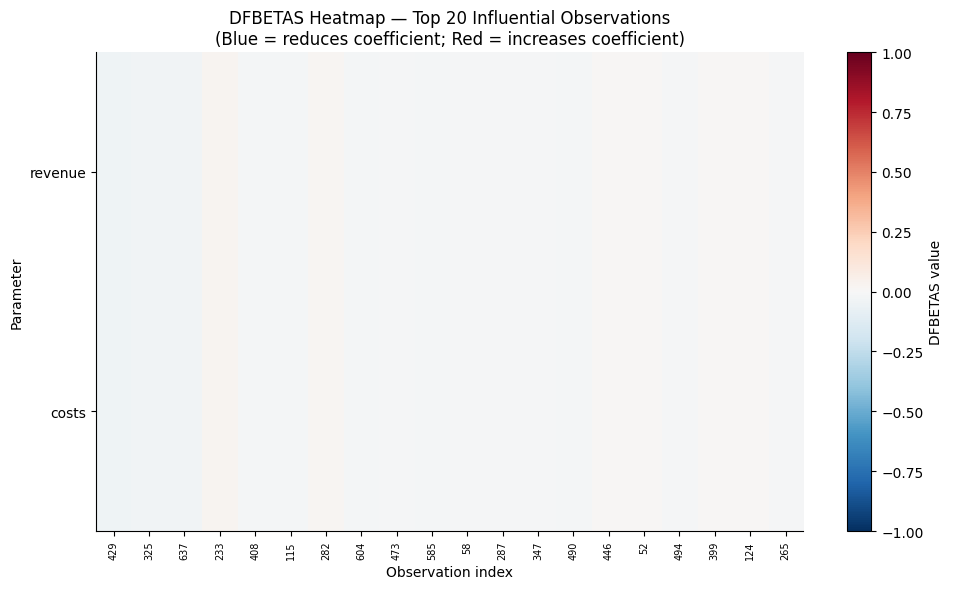

Saved: outputs/03_dfbetas_heatmap.png


In [15]:
# Cell 5.4 — DFBETAS Heatmap for Top 20 Influential Observations
top20_idx = cooks_d.nlargest(20).index
dfbetas_top20 = dfbetas.loc[top20_idx]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    dfbetas_top20.T.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)
ax.set_xticks(range(len(top20_idx)))
ax.set_xticklabels([str(i) for i in top20_idx], rotation=90, fontsize=7)
ax.set_yticks(range(len(dfbetas.columns)))
ax.set_yticklabels(dfbetas.columns)
ax.set_xlabel("Observation index")
ax.set_ylabel("Parameter")
ax.set_title("DFBETAS Heatmap — Top 20 Influential Observations\n"
             "(Blue = reduces coefficient; Red = increases coefficient)")
plt.colorbar(im, ax=ax, label="DFBETAS value")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_dfbetas_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_dfbetas_heatmap.png")

---
## Section 6 — Leave-One-Out Sensitivity Analysis

### Why Entity-Level LOO?

Observation-level diagnostics (Cook's D, DFFITS) identify *individual data points*.
But in panel data the entity is often the unit of analysis — a single firm or country
may appear in many observations, collectively driving the result.

**Leave-one-out (LOO) at entity level:**

- Remove **all** observations for entity i  
- Refit the model on the remaining N−1 entities  
- Compare β̂₍₋ᵢ₎ with baseline β̂  

**Metric:** percentage deviation from baseline  
$$\Delta_i = \max_j \left| \frac{\hat{\beta}_j^{(-i)} - \hat{\beta}_j}{\hat{\beta}_j} \right| \times 100$$

This is commonly requested by peer reviewers:
*"Are your results robust to excluding country X?"*

### Interpretation Guide

| Max % deviation | Interpretation |
|-----------------|---------------|
| < 5% | Highly stable estimates |
| 5–20% | Moderate sensitivity; investigate those entities |
| > 20% | Results driven by a specific entity; report separately |

In [16]:
# Cell 6.2 — LOO by Entity
fe_real = FixedEffects(
    formula="roe ~ leverage + firm_age",
    data=df_firms,
    entity_col="firm",
    time_col="year",
).fit()

sensitivity = SensitivityAnalysis(fe_real)
loo_entities = sensitivity.leave_one_out_entities()

# Compute % deviation from baseline for each excluded entity
baseline_params = sensitivity.params
estimates_df    = loo_entities.estimates

# Max absolute % deviation across all parameters
pct_dev = estimates_df.sub(baseline_params).div(baseline_params.abs()).abs().mul(100)
loo_entities_summary = pct_dev.max(axis=1).rename("max_deviation_pct").reset_index()
loo_entities_summary.columns = ["excluded_entity", "max_deviation_pct"]

print("LOO Entity Results (max % deviation from baseline):")
print(loo_entities_summary.sort_values("max_deviation_pct", ascending=False).head(10))

LOO Entity Results (max % deviation from baseline):
    excluded_entity  max_deviation_pct
4            excl_5         124.860962
69          excl_70         113.433034
91          excl_92         100.274796
80          excl_81          99.830967
26          excl_27          90.699322
28          excl_29          90.000416
84          excl_85          85.613495
100        excl_101          83.918127
94          excl_95          83.077050
98          excl_99          82.979800


In [17]:
# Cell 6.3 — LOO by Period
loo_periods = sensitivity.leave_one_out_periods()

estimates_periods_df = loo_periods.estimates
pct_dev_periods = (
    estimates_periods_df
    .sub(baseline_params)
    .div(baseline_params.abs())
    .abs()
    .mul(100)
)
loo_periods_summary = pct_dev_periods.max(axis=1).rename("max_deviation_pct").reset_index()
loo_periods_summary.columns = ["excluded_period", "max_deviation_pct"]

print("LOO Period Results (max % deviation from baseline):")
print(loo_periods_summary.sort_values("max_deviation_pct", ascending=False))

LOO Period Results (max % deviation from baseline):
  excluded_period  max_deviation_pct
3       excl_2021          79.186604
4       excl_2022          61.078897
1       excl_2019          52.477061
0       excl_2018          24.930037
2       excl_2020           8.118476


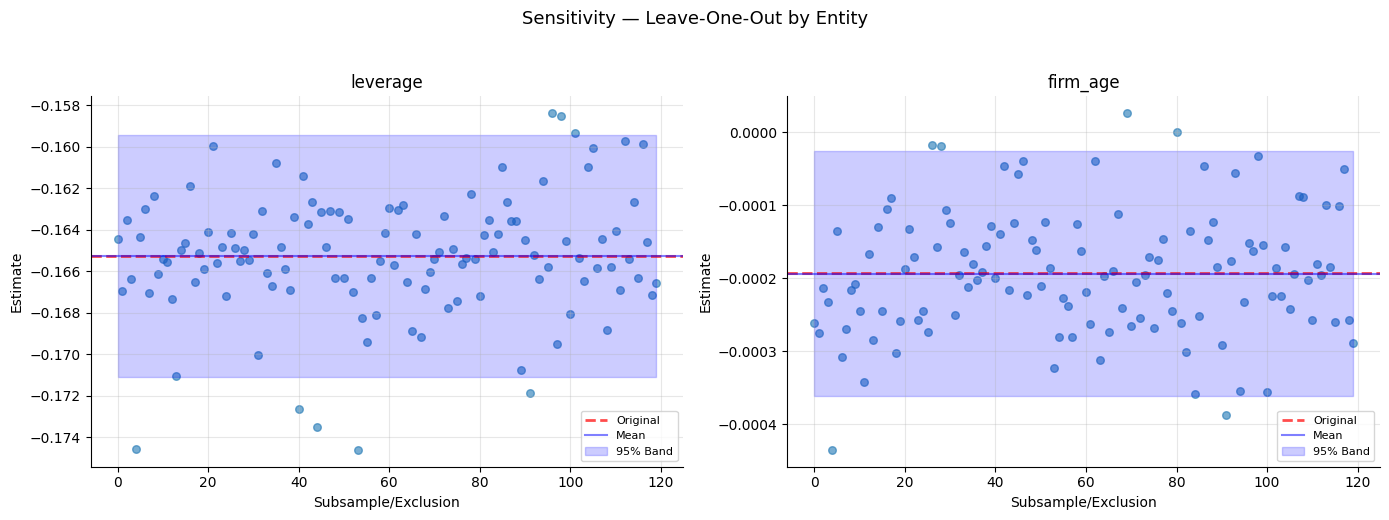

Saved: outputs/03_loo_sensitivity.png


In [18]:
# Cell 6.4 — Visualize LOO Entity Sensitivity
# SensitivityAnalysis.plot_sensitivity shows coefficient traces across exclusions
fig = sensitivity.plot_sensitivity(
    loo_entities,
    params=list(baseline_params.index),
    figsize=(14, 5),
)
fig.suptitle("Sensitivity — Leave-One-Out by Entity", fontsize=13, y=1.03)
fig.savefig(OUTPUT_DIR / "03_loo_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_loo_sensitivity.png")

In [19]:
# Cell 6.5 — Summary Table
n_highly_sensitive = (loo_entities_summary["max_deviation_pct"] > 20).sum()
n_moderately_sensitive = (
    (loo_entities_summary["max_deviation_pct"] > 5) &
    (loo_entities_summary["max_deviation_pct"] <= 20)
).sum()
n_stable = (loo_entities_summary["max_deviation_pct"] <= 5).sum()

print("\nLOO Entity Sensitivity Summary:")
print(f"  Stable (< 5% deviation)        : {n_stable} entities")
print(f"  Moderate (5–20% deviation)     : {n_moderately_sensitive} entities")
print(f"  High sensitivity (> 20%)       : {n_highly_sensitive} entities")

if n_highly_sensitive > 0:
    influential_entities = loo_entities_summary[
        loo_entities_summary["max_deviation_pct"] > 20
    ].sort_values("max_deviation_pct", ascending=False)
    print("\nHighly influential entities:")
    print(influential_entities)


LOO Entity Sensitivity Summary:
  Stable (< 5% deviation)        : 15 entities
  Moderate (5–20% deviation)     : 29 entities
  High sensitivity (> 20%)       : 76 entities

Highly influential entities:
   excluded_entity  max_deviation_pct
4           excl_5         124.860962
69         excl_70         113.433034
91         excl_92         100.274796
80         excl_81          99.830967
26         excl_27          90.699322
..             ...                ...
48         excl_49          23.602642
87         excl_88          23.430034
56         excl_57          22.816821
96         excl_97          21.336579
95         excl_96          20.009597

[76 rows x 2 columns]


---
## Section 7 — Case Study: Diagnosis and Decision

### Scenario

Dataset: `panel_with_outliers.csv`. A researcher fits a Fixed Effects model and
suspects some observations may be data-entry errors (the dataset was assembled
by merging multiple administrative sources). She has already identified outliers
using residual diagnostics.

**Goal:** compare three treatment strategies and choose the most defensible approach.

| Strategy | Description | When to prefer |
|----------|-------------|---------------|
| **Option A** | Remove detected outliers, refit | Strong evidence of data errors |
| **Option B** | Keep all observations, cluster-robust SEs | Outliers are legitimate but inflate variance |
| **Preferred** | Keep all, report Options A & B as robustness checks | CIs overlap → results are robust |

In [20]:
# Cell 7.2 — Step 1: Baseline Fit
print("=" * 60)
print("BASELINE FE MODEL (all observations)")
print("=" * 60)
print(fe_outliers.summary())

BASELINE FE MODEL (all observations)
                       Fixed Effects Estimation Results                       
Formula: profit ~ revenue + costs
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:                 640
No. Entities:                      80
No. Time Periods:                   8
Degrees of Freedom:               558
R-squared:                     0.1760
Adj. R-squared:                0.0564
R-squared (within):            0.1760
R-squared (between):           1.0000
R-squared (overall):           0.7397
Standard Errors:            nonrobust
F-statistic (FE vs OLS):       1.2026
F-test p-value:                0.1247
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
revenue              1.1032      0.1011  10.915  0.0000    0.9047    1.3017 ***
costs               -1.0619      0.1271  -8.353  0.

In [21]:
# Cell 7.3 — Step 2: Full Influence Diagnostics
influence_full = InfluenceDiagnostics(fe_outliers)
infl_full_results = influence_full.compute()

top5_cook = infl_full_results.cooks_d.nlargest(5).index.tolist()
print("Top 5 observations by Cook's D:")
print(df_outliers.loc[top5_cook, ["firm", "year", "profit", "revenue",
                                   "costs", "outlier_flag"]])
print("\nCook's D values:")
print(infl_full_results.cooks_d.loc[top5_cook].round(5))

Computing influence diagnostics...
Influence diagnostics computed successfully
Top 5 observations by Cook's D:
     firm  year    profit   revenue     costs  outlier_flag
429    54  2020   35.2258  490.0211  308.6845             1
325    41  2020  -43.6622  391.2696  249.6357             1
637    80  2020   57.6939  506.6400  300.3402             1
233    30  2016  194.3187  108.0425   56.3750             1
408    52  2015  -86.6209  246.5233  160.4015             1

Cook's D values:
429    0.09335
325    0.09114
637    0.07633
233    0.05967
408    0.05889
dtype: float64


In [22]:
# Cell 7.4 — Step 3: Option A — Remove Detected Outliers
# Use the studentised residual results from Section 2
outlier_row_indices = outlier_table_stud.index.tolist()
df_clean = df_outliers.drop(index=outlier_row_indices).reset_index(drop=True)

print(f"Original dataset: {len(df_outliers)} observations")
print(f"After removing outliers: {len(df_clean)} observations")
print(f"Removed: {len(df_outliers) - len(df_clean)} observations")

fe_option_a = FixedEffects(
    formula="profit ~ revenue + costs",
    data=df_clean,
    entity_col="firm",
    time_col="year",
).fit()

print("\n" + "=" * 60)
print("OPTION A: Remove detected outliers")
print("=" * 60)
print(fe_option_a.summary())

Original dataset: 640 observations
After removing outliers: 620 observations
Removed: 20 observations

OPTION A: Remove detected outliers
                       Fixed Effects Estimation Results                       
Formula: profit ~ revenue + costs
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:                 620
No. Entities:                      80
No. Time Periods:                   8
Degrees of Freedom:               538
R-squared:                     0.4824
Adj. R-squared:                0.4045
R-squared (within):            0.4824
R-squared (between):           1.0000
R-squared (overall):           0.9405
Standard Errors:            nonrobust
F-statistic (FE vs OLS):       1.6088
F-test p-value:                0.0014
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
revenue              0.9926   

In [23]:
# Cell 7.5 — Step 4: Option B — Cluster-Robust SEs (Keep All Observations)
fe_option_b = FixedEffects(
    formula="profit ~ revenue + costs",
    data=df_outliers,
    entity_col="firm",
    time_col="year",
).fit(cov_type="clustered")

print("=" * 60)
print("OPTION B: Cluster-robust SEs (all observations)")
print("=" * 60)
print(fe_option_b.summary())

OPTION B: Cluster-robust SEs (all observations)
                       Fixed Effects Estimation Results                       
Formula: profit ~ revenue + costs
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:                 640
No. Entities:                      80
No. Time Periods:                   8
Degrees of Freedom:               558
R-squared:                     0.1760
Adj. R-squared:                0.0564
R-squared (within):            0.1760
R-squared (between):           1.0000
R-squared (overall):           0.7397
Standard Errors:            clustered
F-statistic (FE vs OLS):       1.2026
F-test p-value:                0.1247
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
revenue              1.1032      0.1012  10.904  0.0000    0.9045    1.3019 ***
costs               -1.0619      0.1125 

Coefficient on 'revenue' across specifications:
  Baseline (naive)            : 1.1032  [95% CI: 0.9051, 1.3013]
  Option A (no outliers)      : 0.9926  [95% CI: 0.9055, 1.0797]
  Option B (cluster SE)       : 1.1032  [95% CI: 0.9049, 1.3015]


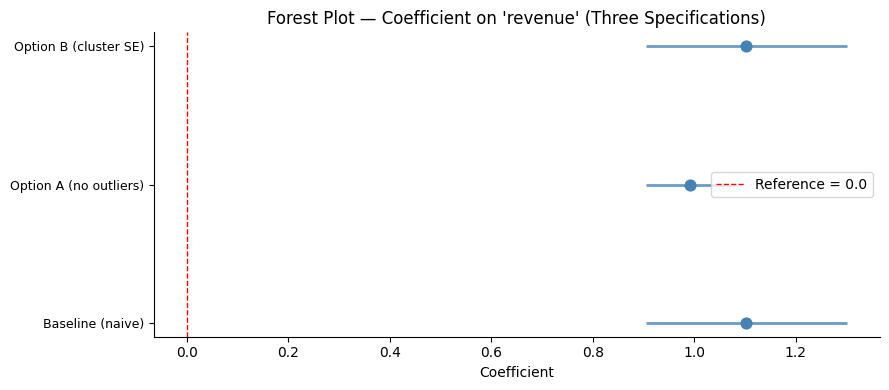

Saved: outputs/03_forest_plot.png


In [24]:
# Cell 7.6 — Step 5: Forest Plot Comparison
# Compare all three specifications for the 'revenue' coefficient
models = {
    "Baseline (naive)": fe_outliers,
    "Option A (no outliers)": fe_option_a,
    "Option B (cluster SE)": fe_option_b,
}

param_name = "revenue"

estimates_arr = np.array([m.params[param_name] for m in models.values()])
se_arr        = np.array([m.std_errors[param_name] for m in models.values()])
labels_list   = list(models.keys())

print(f"Coefficient on '{param_name}' across specifications:")
for label, est, se in zip(labels_list, estimates_arr, se_arr):
    lo95, hi95 = est - 1.96*se, est + 1.96*se
    print(f"  {label:<28}: {est:.4f}  [95% CI: {lo95:.4f}, {hi95:.4f}]")

fig = plot_forest_plot(
    estimates=estimates_arr,
    se=se_arr,
    labels=labels_list,
    title=f"Forest Plot — Coefficient on '{param_name}' (Three Specifications)",
    figsize=(9, 4),
)
fig.savefig(OUTPUT_DIR / "03_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_forest_plot.png")

In [25]:
# Cell 7.7 — Quantitative Robustness Check
# Check whether the 95% CIs across specifications overlap substantially
from scipy.stats import norm as sp_norm

z = sp_norm.ppf(0.975)  # 1.96

intervals = {
    label: (est - z*se, est + z*se)
    for label, est, se in zip(labels_list, estimates_arr, se_arr)
}

# Global overlap: intersection of all three CIs
global_lo = max(lo for lo, hi in intervals.values())
global_hi = min(hi for lo, hi in intervals.values())
overlap = global_hi - global_lo

print("=" * 60)
print("ROBUSTNESS ASSESSMENT")
print("=" * 60)
if overlap > 0:
    print(f"All three 95% CIs share a common interval: [{global_lo:.4f}, {global_hi:.4f}]")
    print("=> Conclusion: coefficient estimates are ROBUST across all three specifications.")
    print("   Recommend: keep baseline + report Options A & B as Appendix robustness checks.")
else:
    print("WARNING: The three 95% CIs do NOT share a common overlap.")
    print("=> Conclusion: results are SENSITIVE to outlier treatment.")
    print("   Recommend: report all three specifications; investigate outlier nature.")

ROBUSTNESS ASSESSMENT
All three 95% CIs share a common interval: [0.9055, 1.0797]
=> Conclusion: coefficient estimates are ROBUST across all three specifications.
   Recommend: keep baseline + report Options A & B as Appendix robustness checks.


---
## Section 8 — Decision Guide and Best Practices

### Decision Framework

```
Influential observation detected
          │
          ▼
    Is it a data error?
    (implausible value,
     misrecorded, impossible)
         │           │
        YES          NO
         │           │
         ▼           ▼
    Correct or    Does removing it
    remove it     change conclusions?
                      │       │
                     YES      NO
                      │       │
                      ▼       ▼
               Report both   Keep all obs;
               with and      report Cook's D
               without as    analysis in
               robustness    appendix
               checks
```

### Rules of Thumb

1. **Never silently drop observations.** Every exclusion must be documented and justified.

2. **Residual threshold of 3σ is a guide, not a law.** In large panels, many
   observations will exceed 2.5σ by chance (5% of a normal distribution). Use
   Cook's D as the primary influence filter.

3. **Cluster-robust SEs (Option B) are conservative but honest.** They inflate
   standard errors to account for within-cluster correlation that may be
   exaggerated by outliers.

4. **LOO analysis is the gold standard for peer review.** Including a table
   showing "results hold when entity X is excluded" dramatically increases
   credibility.

5. **Report the forest plot.** Overlapping confidence intervals provide visual
   evidence of robustness that reviewers find compelling.

---
## Key Concepts Glossary

| Term | Definition |
|------|----------|
| **Outlier** | Observation with an unusually large residual |
| **Leverage** | Degree to which an observation's X value is extreme; measured by hat value hᵢᵢ |
| **Influential observation** | Observation whose removal causes a substantial change in β̂ |
| **Cook's Distance** | Composite measure combining residual magnitude and leverage |
| **DFFITS** | Change in fitted value when observation removed, standardised |
| **DFBETAS** | Change in each coefficient when observation removed, standardised |
| **Leave-one-out** | Refitting the model N times, each time omitting one entity/period |
| **Studentised residual** | Residual divided by leave-one-out standard deviation |

---
## Summary of Output Files

| File | Content |
|------|---------|
| `outputs/03_studentised_residuals.png` | Histogram + index plot of studentised residuals |
| `outputs/03_leverage_vs_residuals.png` | Leverage vs. standardised residuals scatter plot |
| `outputs/03_cooks_distance.png` | Cook's D index plot with threshold |
| `outputs/03_dfbetas_heatmap.png` | DFBETAS heatmap for top 20 observations |
| `outputs/03_loo_sensitivity.png` | LOO entity sensitivity traces |
| `outputs/03_forest_plot.png` | Forest plot comparing three specifications |

In [26]:
# Final cell — Confirm all output files were written
import os

expected_outputs = [
    "03_studentised_residuals.png",
    "03_leverage_vs_residuals.png",
    "03_cooks_distance.png",
    "03_dfbetas_heatmap.png",
    "03_loo_sensitivity.png",
    "03_forest_plot.png",
]

print("Output file status:")
all_ok = True
for fname in expected_outputs:
    fpath = OUTPUT_DIR / fname
    exists = fpath.exists()
    size_kb = fpath.stat().st_size / 1024 if exists else 0
    status = f"OK ({size_kb:.1f} KB)" if exists else "MISSING"
    print(f"  {'[OK]' if exists else '[!!]'}  {fname:<40}  {status}")
    if not exists:
        all_ok = False

print()
if all_ok:
    print("All output files present. Notebook completed successfully.")
else:
    print("WARNING: Some output files are missing. Re-run affected cells.")

Output file status:
  [OK]  03_studentised_residuals.png              OK (125.9 KB)
  [OK]  03_leverage_vs_residuals.png              OK (125.7 KB)
  [OK]  03_cooks_distance.png                     OK (46.4 KB)
  [OK]  03_dfbetas_heatmap.png                    OK (65.1 KB)
  [OK]  03_loo_sensitivity.png                    OK (109.5 KB)
  [OK]  03_forest_plot.png                        OK (38.8 KB)

All output files present. Notebook completed successfully.
